# 3.5 — Living with estimation error and regime change

> *"It is difficult to make predictions, especially about the future."* — Danish proverb, usually
> attributed to Niels Bohr, always true of hedge ratios

## The problem

Every hedge ratio and every covariance in this tutorial was estimated on a window of history and then
*used tomorrow*. That is a forecast, and forecasts have two enemies:

* **Sampling error** — a short window gives a noisy ratio (Chapter 3.2's error bars).
* **Non-stationarity** — a long window averages over regimes that no longer apply (Chapter 1.5's crisis).

They pull in opposite directions: shorter windows track change but are noisy; longer windows are precise
about a world that may have ended. This chapter measures the trade-off **out of sample** — the only
honest way — introduces exponentially-weighted and shrinkage estimators that soften it, and ends with
what a hedger should *do* when the model is visibly breaking.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd().resolve()
while not (_root / "gashedge").exists():
    _root = _root.parent
sys.path.insert(0, str(_root))

from datetime import date
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from gashedge import get_logger
from gashedge.plotting import setup_style

from gashedge.market_data import simulate_hub_history
from gashedge.hedging import ols, min_variance_hedge_ratio, rolling_hedge_ratio, ewma_hedge_ratio
from gashedge.plotting import plot_series
setup_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
log = get_logger("ch3.5")
log.info("Environment ready")

2026-09-13 16:47:18.590 | INFO    | ch3.5 | Environment ready


## 1. The ratio through a crisis

We use the hub history with a 2022-style crisis in its middle third. The full-sample ratio is *one*
number; the rolling and EWMA ratios are *paths*. Which would you rather have been hedging with?

2026-09-13 16:47:18.601 | INFO    | gashedge.market_data | Simulated 1000 days of hub history (crisis=True); TTF range 17.9-379.6


2026-09-13 16:47:18.686 | INFO    | ch3.5 | Full-sample h=0.705; by regime: {'calm-1': 0.992, 'crisis': 0.699, 'calm-2': 1.0}


,h,corr,sigma_S/sigma_F
calm-1,0.992,0.967,1.026
crisis,0.699,0.976,0.717
calm-2,1.000,0.952,1.050


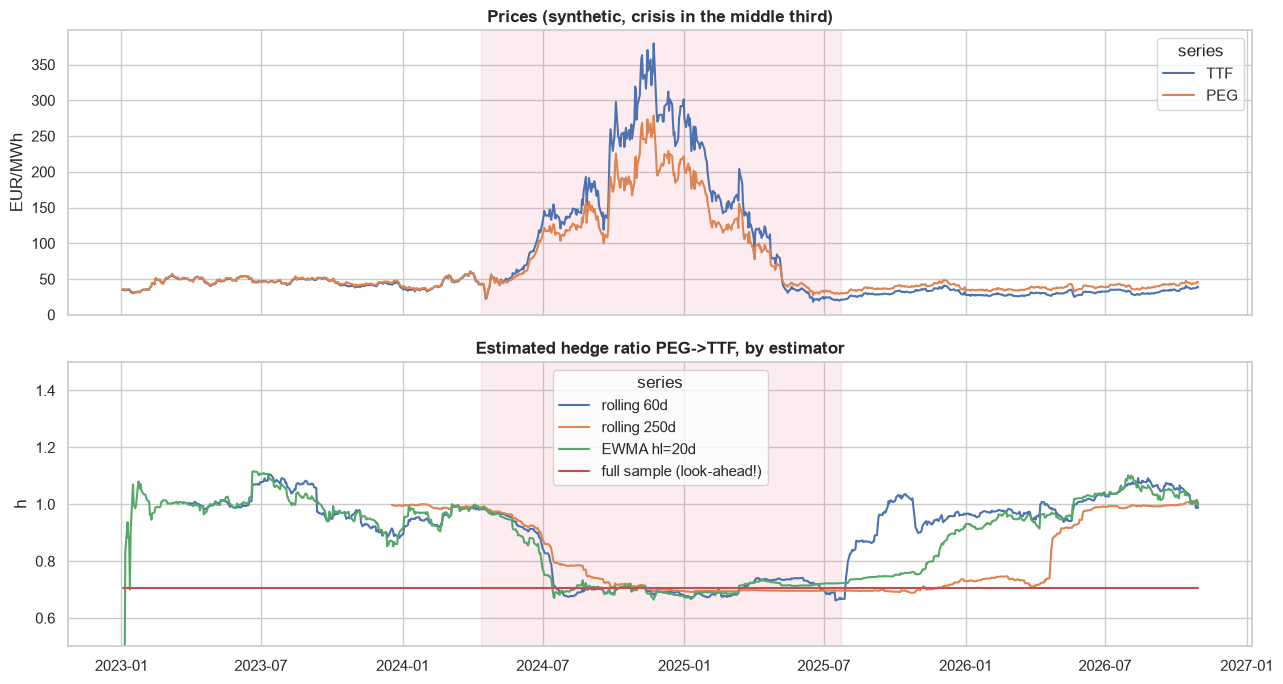

In [2]:
hist = simulate_hub_history(n_days=1000, crisis=True)
dS, dF = hist.PEG.diff().dropna(), hist.TTF.diff().dropna()
n = len(dS)
lo, hi = n // 3, 2 * n // 3
regime = pd.Series("calm-1", index=dS.index); regime.iloc[lo:hi] = "crisis"; regime.iloc[hi:] = "calm-2"

h_full = min_variance_hedge_ratio(dS, dF)
ratios = pd.DataFrame({
    "rolling 60d": rolling_hedge_ratio(dS, dF, 60),
    "rolling 250d": rolling_hedge_ratio(dS, dF, 250),
    "EWMA hl=20d": ewma_hedge_ratio(dS, dF, 20),
    "full sample (look-ahead!)": h_full,
})
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
plot_series(hist[["TTF", "PEG"]], title="Prices (synthetic, crisis in the middle third)", ax=axes[0])
plot_series(ratios, title="Estimated hedge ratio PEG->TTF, by estimator", ylabel="h", ax=axes[1]); axes[1].set_ylim(0.5, 1.5)
for ax in axes:
    ax.axvspan(dS.index[lo], dS.index[hi], color="crimson", alpha=0.08)
plt.tight_layout()
by_regime = pd.DataFrame({r: {"h": min_variance_hedge_ratio(dS[regime == r], dF[regime == r]), "corr": dS[regime == r].corr(dF[regime == r]),
                              "sigma_S/sigma_F": dS[regime == r].std() / dF[regime == r].std()} for r in ("calm-1", "crisis", "calm-2")}).T
log.info("Full-sample h=%.3f; by regime: %s", h_full, by_regime.h.round(3).to_dict())
by_regime.round(3)

## 2. Out-of-sample: the only test that counts

In-sample $R^2$ flatters every estimator (it saw the answer). The honest procedure: on each day $t$,
estimate $\hat h_t$ from data **up to $t-1$**, hedge with it, record the realised residual
$\Delta S_t - \hat h_t\Delta F_t$. Then compare the realised residual variance across estimators — and
across regimes.

In [3]:
candidates = {
    "1:1 (no estimation)": pd.Series(1.0, index=dS.index),
    "rolling 30d": rolling_hedge_ratio(dS, dF, 30),
    "rolling 60d": rolling_hedge_ratio(dS, dF, 60),
    "rolling 250d": rolling_hedge_ratio(dS, dF, 250),
    "EWMA hl=10d": ewma_hedge_ratio(dS, dF, 10),
    "EWMA hl=30d": ewma_hedge_ratio(dS, dF, 30),
    "EWMA hl=90d": ewma_hedge_ratio(dS, dF, 90),
    "expanding (all past)": pd.Series([min_variance_hedge_ratio(dS.iloc[:k], dF.iloc[:k]) if k >= 30 else np.nan for k in range(1, n + 1)], index=dS.index),
}
start = 250   # evaluate only where every estimator has data
rows = []
for name, h in candidates.items():
    h_used = h.shift(1)                      # yesterday's estimate hedges today
    resid = (dS - h_used * dF).iloc[start:]
    row = {"estimator": name, "OOS residual std (all)": resid.std()}
    for r in ("calm-1", "crisis", "calm-2"):
        mask = (regime == r).iloc[start:]
        if mask.sum() > 20:
            row[f"OOS std {r}"] = resid[mask].std()
    row["h volatility (std of daily h)"] = h.iloc[start:].std()
    rows.append(row)
oos = pd.DataFrame(rows).set_index("estimator")
unhedged = pd.Series({"all": dS.iloc[start:].std(), **{r: dS.iloc[start:][(regime == r).iloc[start:]].std() for r in ("crisis", "calm-2")}})
log.info("Unhedged std: %s", unhedged.round(2).to_dict())
log.info("Best OOS overall: %s (%.2f); 1:1 gives %.2f", oos["OOS residual std (all)"].idxmin(), oos["OOS residual std (all)"].min(), oos.loc["1:1 (no estimation)", "OOS residual std (all)"])
oos.round(3)

2026-09-13 16:47:18.911 | INFO    | ch3.5 | Unhedged std: {'all': 6.48, 'crisis': 9.62, 'calm-2': 1.01}


2026-09-13 16:47:18.912 | INFO    | ch3.5 | Best OOS overall: EWMA hl=10d (1.43); 1:1 gives 3.05


,OOS residual std (all),OOS std calm-1,OOS std crisis,OOS std calm-2,h volatility (std of daily h)
estimator,,,,,
1:1 (no estimation),3.047,0.387,4.559,0.307,0.000
rolling 30d,1.441,0.413,2.131,0.314,0.148
rolling 60d,1.440,0.399,2.128,0.317,0.139
rolling 250d,1.464,0.388,2.158,0.367,0.130
EWMA hl=10d,1.435,0.404,2.120,0.319,0.141
EWMA hl=30d,1.438,0.396,2.121,0.352,0.122
EWMA hl=90d,1.457,0.389,2.138,0.415,0.101
expanding (all past),1.488,0.387,2.185,0.418,0.109


Study the table column by column — the regimes tell different stories:

* **Through the crisis, every adaptive estimator beats 1:1 by a wide margin.** The true ratio fell to
  ~0.7; a desk still hedging 1:1 was carrying a 30 % naked TTF short on top of its PEG book. Any window
  that *noticed* did far better than none.
* **In the calm regime after the crisis, 1:1 is competitive again — and the long windows are the worst.**
  The 250-day ratio and the 90-day EWMA are still reporting *crisis* numbers months later: they under-hedge
  a relationship that has already healed. Short windows lose only a little to 1:1 here, the price of
  estimation noise. Remember the quadratic penalty: $\text{extra variance} = (\hat h - h)^2\sigma_F^2$,
  and $\mathbb{E}[(\hat h-h)^2] = \text{se}^2 \propto 1/n$.
* **A short EWMA is the sweet spot overall** — it forgets smoothly rather than falling off a cliff when
  an old observation leaves a window, and it re-learns the calm ratio within weeks.
* **When the structural ratio is near your default, estimation buys little; when the regime moves it
  away, estimation is everything.** For tenor mismatches (Chapter 2.3) the ratio is *always* far from 1,
  so there estimation is never optional.

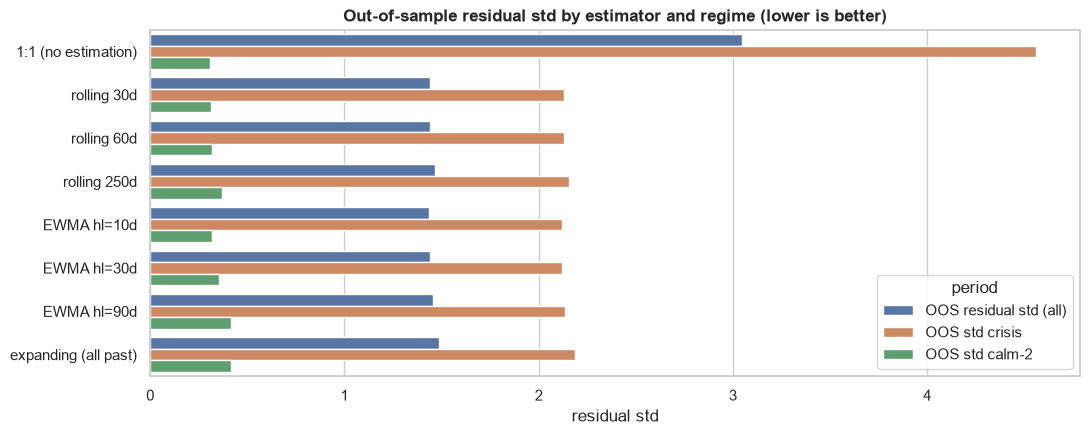

In [4]:
fig, ax = plt.subplots(figsize=(12, 4.5))
sub = oos[["OOS residual std (all)", "OOS std crisis", "OOS std calm-2"]].reset_index().melt(id_vars="estimator", var_name="period", value_name="residual std")
sns.barplot(data=sub, y="estimator", x="residual std", hue="period", ax=ax)
ax.set_title("Out-of-sample residual std by estimator and regime (lower is better)"); ax.set_ylabel("");

## 3. The bias–variance trade-off, written down

Let the true (slowly drifting) ratio be $h_t$ and the estimate from a window of $n$ days $\hat h_t$. The
expected extra variance from using $\hat h_t$ instead of $h_t$ is

$$
\mathbb{E}\big[(\hat h_t - h_t)^2\big]\,\sigma_F^2
= \Big(\underbrace{\text{bias}_n^2}_{\text{grows with } n \text{ if } h \text{ drifts}}
+ \underbrace{\tfrac{\sigma_S^2(1-\rho^2)}{n\,\sigma_F^2}}_{\text{sampling variance, } \propto 1/n}\Big)\,\sigma_F^2
\tag{3.20}
$$

If $h$ drifts like a random walk with daily step $\delta$, the bias of a window average is of order
$\delta\sqrt{n}$, so $\text{bias}^2 \approx \delta^2 n/3$. Minimising (3.20) over $n$ gives an
optimal window $n^* \propto \big(\sigma_\varepsilon/(\delta\,\sigma_F)\big)$ — **the faster the ratio
drifts, the shorter the window**. An EWMA half-life plays the same role with smoother forgetting.

## 4. Shrinkage: use what you know

We know something the data does not: PEG and TTF are the *same commodity* one pipeline apart, so the
ratio should be near 1. Treat that as a prior $h \sim N(h_0, \tau^2)$ and the OLS estimate as data
$\hat h \sim N(h, \text{se}^2)$. The Bayesian posterior mean is

$$
\tilde h = w\,\hat h + (1-w)\,h_0, \qquad w = \frac{\tau^2}{\tau^2 + \text{se}^2}
\tag{3.21}
$$

When the data are noisy (large se) you lean on the prior; when they are precise you trust them. This is
exactly the behaviour a good trader has by instinct — and it can be written into the hedging engine.

2026-09-13 16:47:19.050 | INFO    | ch3.5 | Shrinkage toward 1.0: helps in calm (e.g. win=20,tau=0.05: 0.317 -> 0.308) but hurts in the crisis (2.127 -> 2.558) because the prior is wrong there


raw std calm-2  shrunk std calm-2  raw std crisis  shrunk std crisis  mean weight on data
window tau                                                                                            
20     0.05           0.317              0.308           2.127              2.558                0.518
       0.10           0.317              0.311           2.127              2.192                0.758
       0.30           0.317              0.316           2.127              2.126                0.955
30     0.05           0.314              0.310           2.131              2.375                0.597
       0.10           0.314              0.312           2.131              2.147                0.820
       0.30           0.314              0.314           2.131              2.129                0.972
60     0.05           0.317              0.313           2.128              2.204                0.729
       0.10           0.317              0.316           2.128              2.135                0.902
       0.30           0.317              0.317           2.128              2.129                0.987

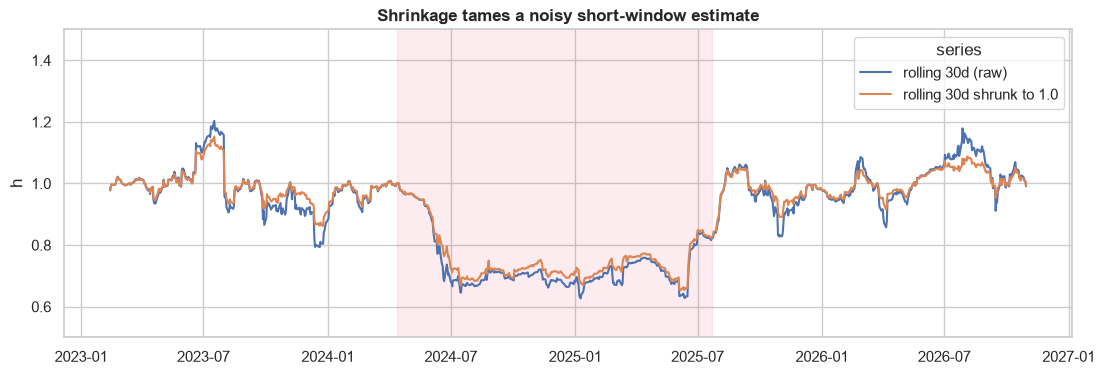

In [5]:
h0, tau = 1.0, 0.10          # prior: ratio near 1, fairly confident (+/- 0.1)
window = 30
def shrunk_series(window, h0, tau):
    h_hat = rolling_hedge_ratio(dS, dF, window)
    # rolling standard error from (3.11)
    rho = dS.rolling(window).corr(dF)
    se = (dS.rolling(window).std() / dF.rolling(window).std()) * np.sqrt((1 - rho**2).clip(lower=0) / window)
    w = tau**2 / (tau**2 + se**2)
    return w * h_hat + (1 - w) * h0, w

rows = []
calm2, crisis_m = (regime == "calm-2").iloc[start:], (regime == "crisis").iloc[start:]
for win in (20, 30, 60):
    raw = rolling_hedge_ratio(dS, dF, win)
    r_raw = (dS - raw.shift(1) * dF).iloc[start:]
    for tau_ in (0.05, 0.10, 0.30):
        shr, w = shrunk_series(win, h0, tau_)
        r_shr = (dS - shr.shift(1) * dF).iloc[start:]
        rows.append({"window": win, "tau": tau_, "raw std calm-2": r_raw[calm2].std(), "shrunk std calm-2": r_shr[calm2].std(),
                     "raw std crisis": r_raw[crisis_m].std(), "shrunk std crisis": r_shr[crisis_m].std(),
                     "mean weight on data": w.iloc[start:].mean()})
shrink_tbl = pd.DataFrame(rows).set_index(["window", "tau"])
log.info("Shrinkage toward %.1f: helps in calm (e.g. win=20,tau=0.05: %.3f -> %.3f) but hurts in the crisis (%.3f -> %.3f) because the prior is wrong there",
         h0, shrink_tbl.loc[(20, 0.05), "raw std calm-2"], shrink_tbl.loc[(20, 0.05), "shrunk std calm-2"],
         shrink_tbl.loc[(20, 0.05), "raw std crisis"], shrink_tbl.loc[(20, 0.05), "shrunk std crisis"])
shr30, w30 = shrunk_series(30, h0, tau)
fig, ax = plt.subplots(figsize=(13, 4))
plot_series(pd.DataFrame({"rolling 30d (raw)": rolling_hedge_ratio(dS, dF, 30), "rolling 30d shrunk to 1.0": shr30}), title="Shrinkage tames a noisy short-window estimate", ylabel="h", ax=ax)
ax.set_ylim(0.5, 1.5); ax.axvspan(dS.index[lo], dS.index[hi], color="crimson", alpha=0.08)
shrink_tbl.round(3)

The table is the whole lesson in miniature. **In the calm regime shrinkage helps** — a little, and most
for the noisiest (shortest) windows, exactly as the theory says. **In the crisis it hurts**, and the
tighter the prior ($\tau = 0.05$) the more it hurts: the prior "the ratio is 1" was simply *wrong* in a
world where PEG had decoupled to 0.7, and confidence in a wrong prior is expensive. Shrinkage is not a free
lunch; it is a bet that your structural knowledge is right. Two practical corollaries:

* The prior should be **structural, not habitual**: for a tenor hedge, the long-run PCA-implied ratio; for
  a hub, the ratio implied by transport economics; for a new hub with little history, a similar hub's ratio.
* The prior's confidence $\tau$ must **widen when the diagnostics fire** (correlation collapse, basis out
  of range — Section 5). A regime change is precisely the moment to trust the data more and the habit less.

## 5. When the model is breaking: what a hedger actually does

Statistics tell you the ratio is uncertain; they do not tell you what to do. Practice does:

1. **Watch the diagnostics, not just the ratio.** Rolling correlation falling through a threshold
   (Chapter 1.5), VaR exceedances clustering (Chapter 3.4), basis leaving its historical range — each is
   a trigger for the steps below, defined *in advance*.
2. **Reduce, don't re-estimate.** When the relationship breaks, no window gives a trustworthy ratio.
   Cut the *residual* — migrate proxies to direct instruments (Chapter 2.4), lay off basis in the basis
   swap market even at a wide spread (Chapter 2.2), tighten bands (Chapter 2.5).
3. **Switch to structural priors.** In a decoupling, the *physical* story (which pipe is full, which
   terminal is saturated) is better information than any regression. Shrink hard toward what the
   physics says; let the data pull you back as it accumulates.
4. **Fund the path.** Regime changes coincide with margin spikes (Chapter 2.2). The hedges that survive
   are the ones whose cash needs were pre-arranged.
5. **Write it down.** The Metallgesellschaft lesson (Chapter 2.4): the decision to hold or unwind must be
   made before the crisis, by people who understand both legs.

## 6. Where this leaves you

You began with a risk report you could not read and a venue you had never traded. You can now:

* translate any line of the report into contracts, hours, lots and expiries (Module 1);
* decide what to hedge with, how much, how often, and how to maintain it — and defend each choice with a
  number (Module 2);
* size hedges by the linear model, attach error bars, hedge factors instead of tenors, report VaR, ES,
  stress and liquidity horizon, and know how far to trust the estimates (Module 3).

What this tutorial deliberately left out — the natural next chapters of your own study:

* **Options and non-linear risk** — gamma and vega hedging, when the MM books carry optionality;
* **Physical assets** — storage, transport and swing valuation, where the hedge is a strategy, not a ratio;
* **Intraday and microstructure** — hedging in event time, adverse selection, latency;
* **Hedge accounting and regulation** — IFRS 9 effectiveness testing (it *is* the $R^2$ of Chapter 3.2),
  EMIR, MiFID II position limits, REMIT.

> *"The purpose of hedging is not to be right about the market. It is to be around for the next one."*

### Check your understanding — and the tutorial's

Work these on paper (or in a scratch cell) *before* expanding the answers.

**Q1.** A 30-day rolling estimate gives $\hat h = 1.22$ with standard error 0.15. Your prior is $h_0 = 1.0$ with $\tau = 0.10$. Compute the shrinkage weight and the posterior ratio. Redo it for a 250-day estimate $\hat h = 1.22$ with se 0.04.

<details><summary><i>Answer 1</i></summary>

$w = \tau^2/(\tau^2 + \text{se}^2) = 0.01/(0.01 + 0.0225) = \mathbf{0.308}$; $\tilde h = 0.308\times1.22 + 0.692\times1.0 = \mathbf{1.068}$. With se $= 0.04$: $w = 0.01/(0.01+0.0016) = \mathbf{0.862}$; $\tilde h = 0.862\times1.22 + 0.138\times1.0 = \mathbf{1.190}$. Same point estimate, very different action: the noisy one is mostly ignored, the precise one mostly believed — and if a *precise* estimate says 1.22 for months, that is evidence the prior itself should move.

</details>

**Q2.** Using (3.20): $\sigma_S = 1.3$, $\sigma_F = 1.2$, $\rho = 0.9$, and the true ratio drifts as a random walk with daily step $\delta = 0.01$. Compare the expected extra variance from sampling error and from drift bias for windows $n = 30$ and $n = 250$ (use $\text{bias}^2 \approx \delta^2 n/3$). Which window is better?

<details><summary><i>Answer 2</i></summary>

Sampling variance of $\hat h$: $\sigma_S^2(1-\rho^2)/(n\sigma_F^2) = 1.69\times0.19/(1.44n) = 0.223/n$: $n=30 \Rightarrow 0.00743$; $n=250 \Rightarrow 0.00089$. Drift bias$^2 \approx \delta^2 n/3 = 10^{-4}n/3$: $n=30 \Rightarrow 0.0010$; $n=250 \Rightarrow 0.0083$. Total $\mathbb{E}[(\hat h-h)^2]$: **0.0084 for 30 days vs 0.0092 for 250 days** — the short window wins slightly here because the drift is fast; multiply by $\sigma_F^2 = 1.44$ for extra variance in (EUR/MWh)² per MWh². Setting the derivative to zero gives $n^* = \sqrt{3\times0.223/10^{-4}} \approx 82$ days — an EWMA half-life around 40–60 days is in the right neighbourhood.

</details>

**Q3.** In the out-of-sample table, the 1:1 hedge often beats the 30-day rolling estimate for the PEG–TTF pair, yet Chapter 2.3 showed estimation is essential for the M12–M1 pair. Reconcile the two.

<details><summary><i>Answer 3</i></summary>

The value of estimation is the bias it removes, $(1 - h^*)^2\sigma_F^2$, versus the noise it adds, $\text{se}^2\sigma_F^2$. For PEG–TTF the true ratio is ≈ 1 so the bias of 1:1 is tiny — smaller than the sampling noise of a short window — and 1:1 wins. For M12–M1 the true ratio is ≈ 0.25, so 1:1 carries a bias of $0.75^2\sigma_F^2$, enormous relative to any estimation noise; estimating (even roughly) is essential. Rule: **estimate when the structural ratio is far from your default, otherwise default and monitor** — and use shrinkage to make the transition continuous.

</details>

**Q4.** Describe a pre-agreed 'regime playbook' for the PEG-hedged-with-TTF book: three triggers, and for each the action and the person who approves it. Why must this exist *before* the regime changes?

<details><summary><i>Answer 4</i></summary>

Example: (1) *Trigger:* 60-day rolling correlation of daily changes < 0.85 or basis outside its 2-year 1st–99th percentile range. *Action:* halve the PEG warehousing limit; begin migrating PEG proxies to cleared PEG–TTF basis swaps up to a pre-set spread cost. *Approver:* desk head. (2) *Trigger:* two VaR exceedances within 10 days or a stress loss > 50 % of the stress limit. *Action:* switch the hedge-ratio engine to EWMA hl=20 with shrinkage to the structural prior, tighten bands by 50 %, recompute liquidity horizons. *Approver:* market risk. (3) *Trigger:* projected variation-margin call > 60 % of the committed liquidity line under the front-spike stress. *Action:* pre-draw the line / reduce gross futures via migration to strips; no forced unwinds. *Approver:* treasury + CRO. It must exist beforehand because during the regime change the data are least trustworthy, the people are most stressed, and the Metallgesellschaft outcome — unwinding a sound hedge at the worst moment — is the default when there is no plan.

</details>


---
◀ [Previous](04_residual_risk_var.ipynb) · [Contents](../00_introduction.ipynb) · [Next ▶](../appendix/A_least_squares.ipynb)